# Chapter 13: Produced Water Treatment and Water Handling

**Production Optimization of Oil and Gas Fields Using NeqSim**

This notebook demonstrates produced water treatment modeling including:
- Three-phase separation with oil, gas, and water phase tracking
- Water cut effect on separator performance
- Hydrocyclone modeling concept for oil-in-water removal
- Sensitivity analysis of water cut on production rates

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch16_water_treatment.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 1. Three-Phase Separation with Water Phase Tracking

We model a three-phase separator handling a well stream with significant
water production. The `ThreePhaseSeparator` in NeqSim splits the feed into
gas, oil, and water outlet streams, enabling tracking of water quality and
oil carryover.

In [2]:
# jneqsim is bound to the source JVM in the setup cell.

def create_well_fluid(water_fraction):
    """Create a well fluid with specified water fraction (mole fraction)."""
    oil_fraction = 100.0 - water_fraction
    fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 70.0, 50.0)
    fluid.addComponent("nitrogen", 0.3 * oil_fraction / 100.0)
    fluid.addComponent("CO2", 1.0 * oil_fraction / 100.0)
    fluid.addComponent("methane", 30.0 * oil_fraction / 100.0)
    fluid.addComponent("ethane", 6.0 * oil_fraction / 100.0)
    fluid.addComponent("propane", 4.0 * oil_fraction / 100.0)
    fluid.addComponent("i-butane", 1.5 * oil_fraction / 100.0)
    fluid.addComponent("n-butane", 2.5 * oil_fraction / 100.0)
    fluid.addComponent("n-pentane", 3.0 * oil_fraction / 100.0)
    fluid.addComponent("n-hexane", 5.0 * oil_fraction / 100.0)
    fluid.addComponent("n-heptane", 15.0 * oil_fraction / 100.0)
    fluid.addComponent("n-octane", 12.0 * oil_fraction / 100.0)
    fluid.addComponent("water", water_fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid

# Base case: 30% water (mole basis)
fluid_base = create_well_fluid(30.0)

feed = jneqsim.process.equipment.stream.Stream("Well Feed", fluid_base)
feed.setFlowRate(80000.0, "kg/hr")
feed.setTemperature(70.0, "C")
feed.setPressure(50.0, "bara")

# Three-phase separator
separator = jneqsim.process.equipment.separator.ThreePhaseSeparator("HP 3-Phase Sep", feed)

process = jneqsim.process.processmodel.ProcessSystem()
process.add(feed)
process.add(separator)
process.run()

# Results
gas_out = separator.getGasOutStream()
oil_out = separator.getOilOutStream()
water_out = separator.getWaterOutStream()

print("=== Three-Phase Separator Results (Base Case: 30 mol% water) ===")
print(f"Feed flow rate:    {feed.getFlowRate('kg/hr'):.0f} kg/hr")
print(f"Feed pressure:     {feed.getPressure('bara'):.1f} bara")
print(f"Feed temperature:  {feed.getTemperature('C'):.1f} C")
print()
print(f"Gas outlet:   {gas_out.getFlowRate('kg/hr'):.0f} kg/hr  at {gas_out.getPressure('bara'):.1f} bara")
print(f"Oil outlet:   {oil_out.getFlowRate('kg/hr'):.0f} kg/hr  at {oil_out.getPressure('bara'):.1f} bara")
print(f"Water outlet: {water_out.getFlowRate('kg/hr'):.0f} kg/hr  at {water_out.getPressure('bara'):.1f} bara")

=== Three-Phase Separator Results (Base Case: 30 mol% water) ===
Feed flow rate:    80000 kg/hr
Feed pressure:     50.0 bara
Feed temperature:  70.0 C

Gas outlet:   8589 kg/hr  at 50.0 bara
Oil outlet:   60092 kg/hr  at 50.0 bara
Water outlet: 11319 kg/hr  at 50.0 bara


## 2. Water Cut Sensitivity on Separator Performance

As a field matures, the water cut increases. This affects:
- Separator liquid loading
- Oil production rate
- Water treatment capacity requirements

We sweep water fraction from 10% to 80% (mole basis) and track outlet flows.

In [3]:
# Water cut sensitivity study
water_fractions = np.arange(10, 81, 5)  # mole %
gas_flows = []
oil_flows = []
water_flows = []
total_liquid_flows = []

for wf in water_fractions:
    fluid_i = create_well_fluid(float(wf))

    feed_i = jneqsim.process.equipment.stream.Stream("Feed", fluid_i)
    feed_i.setFlowRate(80000.0, "kg/hr")
    feed_i.setTemperature(70.0, "C")
    feed_i.setPressure(50.0, "bara")

    sep_i = jneqsim.process.equipment.separator.ThreePhaseSeparator("Sep", feed_i)

    proc_i = jneqsim.process.processmodel.ProcessSystem()
    proc_i.add(feed_i)
    proc_i.add(sep_i)
    proc_i.run()

    g_flow = sep_i.getGasOutStream().getFlowRate("kg/hr")
    o_flow = sep_i.getOilOutStream().getFlowRate("kg/hr")
    w_flow = sep_i.getWaterOutStream().getFlowRate("kg/hr")

    gas_flows.append(g_flow)
    oil_flows.append(o_flow)
    water_flows.append(w_flow)
    total_liquid_flows.append(o_flow + w_flow)

print(f"{'Water Frac (mol%)':<20} {'Gas (kg/hr)':<14} {'Oil (kg/hr)':<14} {'Water (kg/hr)':<14}")
print("-" * 62)
for i in range(0, len(water_fractions), 3):
    print(f"{water_fractions[i]:<20.0f} {gas_flows[i]:<14.0f} {oil_flows[i]:<14.0f} {water_flows[i]:<14.0f}")

Water Frac (mol%)    Gas (kg/hr)    Oil (kg/hr)    Water (kg/hr) 
--------------------------------------------------------------
10                   9603           67186          3210          
25                   8870           62058          9072          
40                   7958           55682          16359         
55                   6794           47542          25664         
70                   5257           36786          37958         


Figure saved to ../figures/ch16_watercut_sensitivity.png


ch16_water_treatment.ipynb:cell6:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


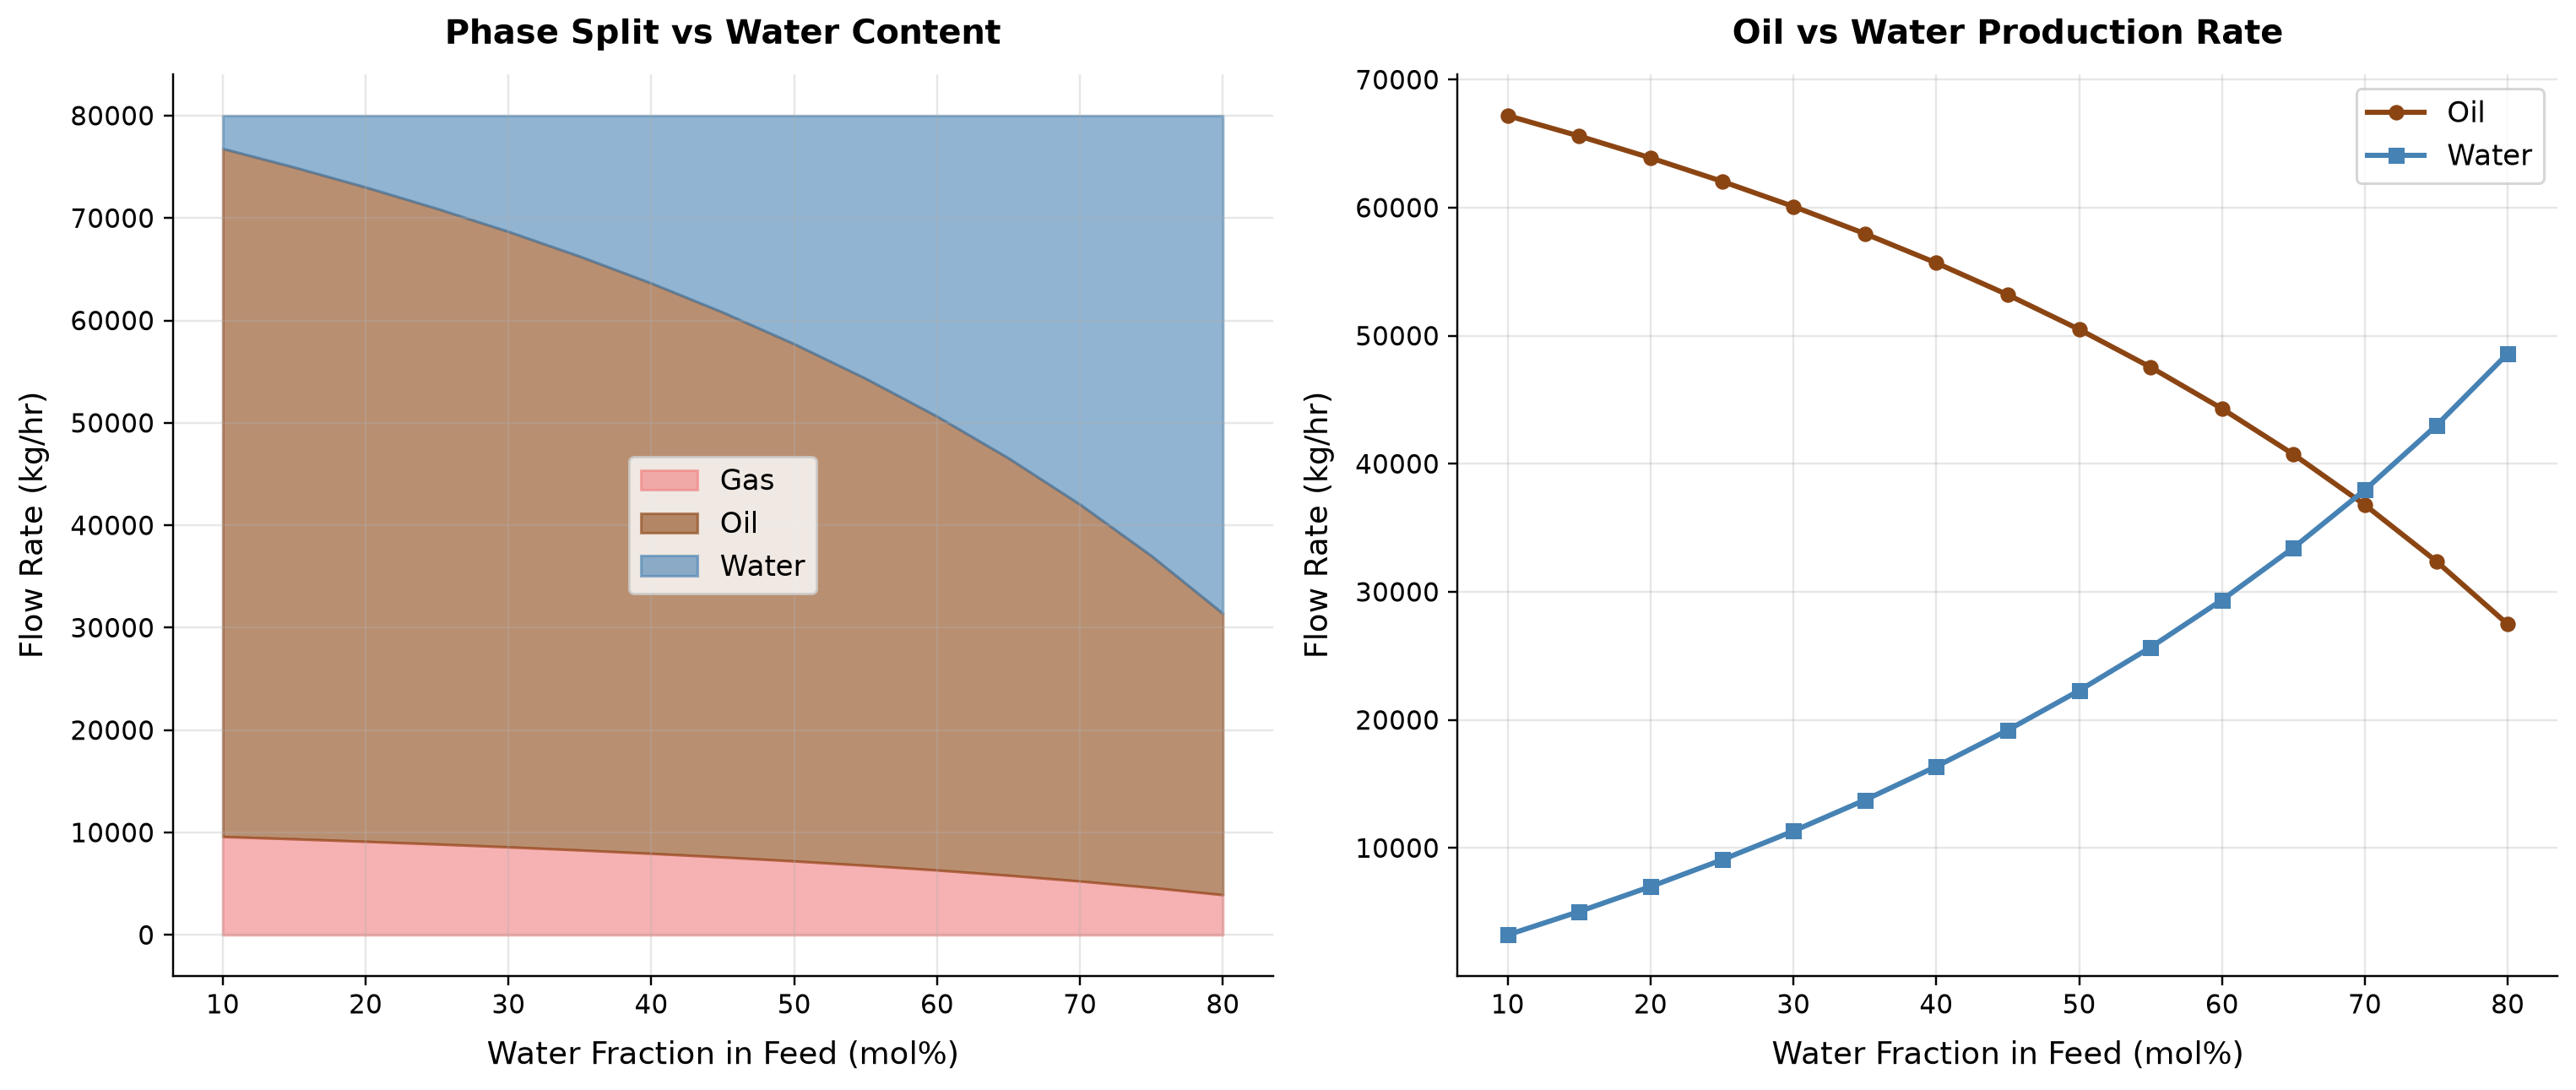

In [4]:
# Plot: Oil and water production vs water fraction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Stacked area plot of outlet flows
ax1.fill_between(water_fractions, 0, gas_flows, alpha=0.6, label="Gas", color="lightcoral")
ax1.fill_between(water_fractions, gas_flows,
                 np.array(gas_flows) + np.array(oil_flows),
                 alpha=0.6, label="Oil", color="saddlebrown")
ax1.fill_between(water_fractions,
                 np.array(gas_flows) + np.array(oil_flows),
                 np.array(gas_flows) + np.array(oil_flows) + np.array(water_flows),
                 alpha=0.6, label="Water", color="steelblue")
ax1.set_xlabel("Water Fraction in Feed (mol%)", fontsize=12)
ax1.set_ylabel("Flow Rate (kg/hr)", fontsize=12)
ax1.set_title("Phase Split vs Water Content", fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Right: Oil production rate vs water fraction
ax2.plot(water_fractions, oil_flows, 'o-', color="saddlebrown", linewidth=2, markersize=5, label="Oil")
ax2.plot(water_fractions, water_flows, 's-', color="steelblue", linewidth=2, markersize=5, label="Water")
ax2.set_xlabel("Water Fraction in Feed (mol%)", fontsize=12)
ax2.set_ylabel("Flow Rate (kg/hr)", fontsize=12)
ax2.set_title("Oil vs Water Production Rate", fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch16_watercut_sensitivity.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved to ../figures/ch16_watercut_sensitivity.png")

**Executed-figure discussion.** Oil: flow rate spans 2.747e+04–6.719e+04 kg/hr across the plotted cases. Water: flow rate spans 3210–4.861e+04 kg/hr across the plotted cases.

Rising water cut redirects produced-fluid handling capacity from hydrocarbon liquid toward water, with phase densities affecting mass-to-volume conversions. Total liquid throughput can remain large while oil production falls, making water treatment and disposal the active constraints. Report oil and water rates separately and evaluate treatment residence time, injection capacity and oil-in-water performance at late-life water cuts.


## 3. Separator Pressure Effect on Water Separation

The separator operating pressure influences flash behavior and the
distribution of light components between gas and liquid phases.
We study pressure from 20 to 80 bara at fixed water cut.

Figure saved to ../figures/ch16_pressure_effect.png


ch16_water_treatment.ipynb:cell8:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


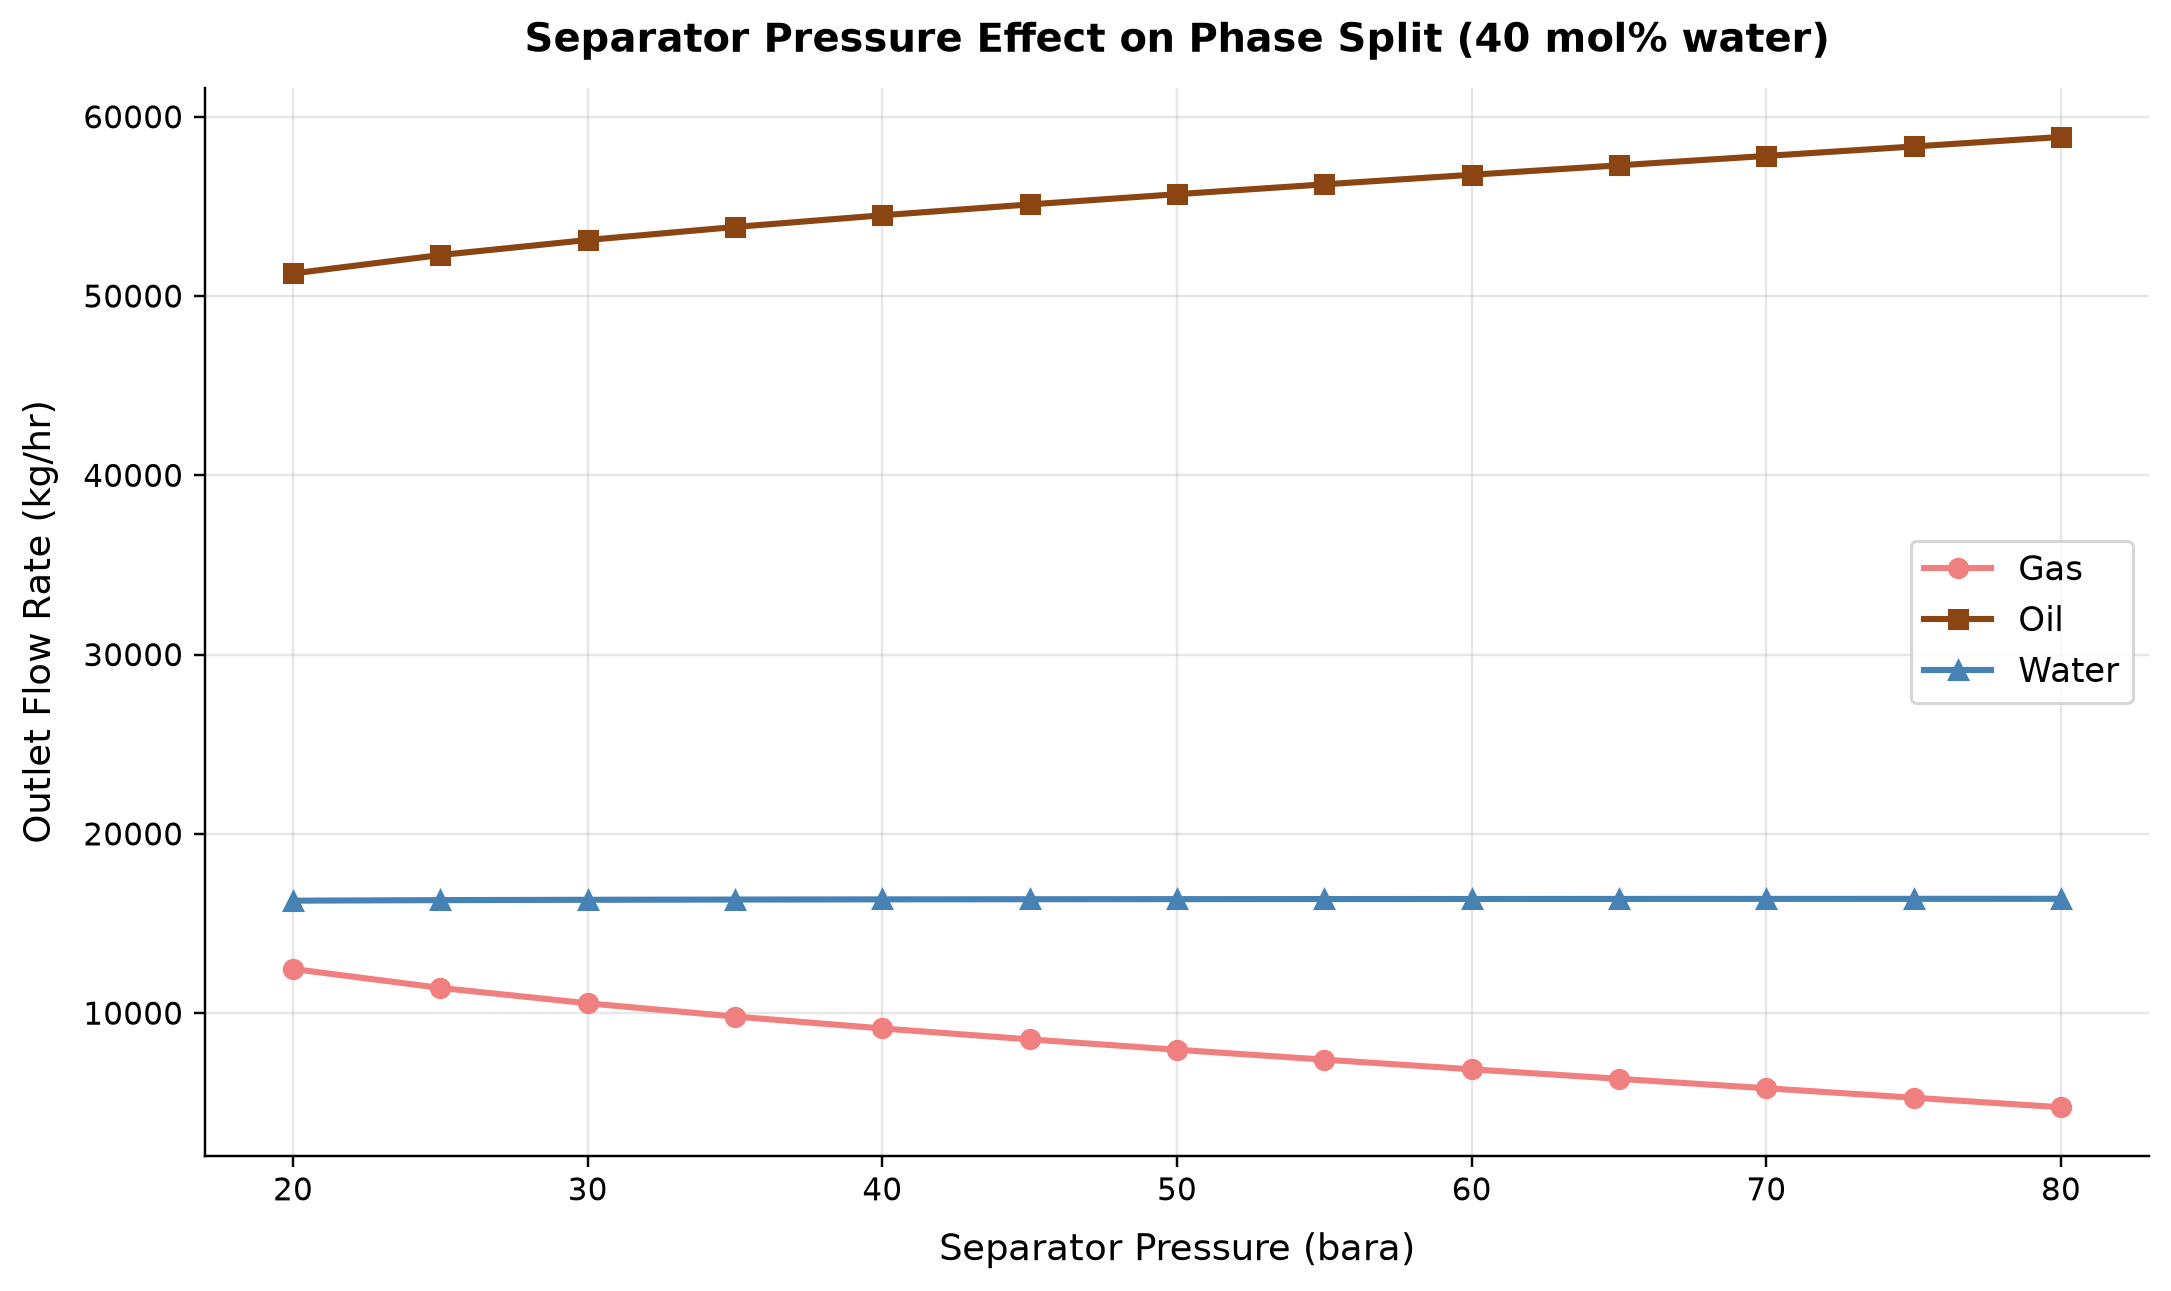

In [5]:
# Pressure sensitivity
pressures = np.arange(20, 81, 5)
gas_flows_p = []
oil_flows_p = []
water_flows_p = []

for p in pressures:
    fluid_p = create_well_fluid(40.0)  # fixed 40 mol% water

    feed_p = jneqsim.process.equipment.stream.Stream("Feed", fluid_p)
    feed_p.setFlowRate(80000.0, "kg/hr")
    feed_p.setTemperature(70.0, "C")
    feed_p.setPressure(float(p), "bara")

    sep_p = jneqsim.process.equipment.separator.ThreePhaseSeparator("Sep", feed_p)

    proc_p = jneqsim.process.processmodel.ProcessSystem()
    proc_p.add(feed_p)
    proc_p.add(sep_p)
    proc_p.run()

    gas_flows_p.append(sep_p.getGasOutStream().getFlowRate("kg/hr"))
    oil_flows_p.append(sep_p.getOilOutStream().getFlowRate("kg/hr"))
    water_flows_p.append(sep_p.getWaterOutStream().getFlowRate("kg/hr"))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pressures, gas_flows_p, 'o-', label="Gas", color="lightcoral", linewidth=2)
ax.plot(pressures, oil_flows_p, 's-', label="Oil", color="saddlebrown", linewidth=2)
ax.plot(pressures, water_flows_p, '^-', label="Water", color="steelblue", linewidth=2)
ax.set_xlabel("Separator Pressure (bara)", fontsize=12)
ax.set_ylabel("Outlet Flow Rate (kg/hr)", fontsize=12)
ax.set_title("Separator Pressure Effect on Phase Split (40 mol% water)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch16_pressure_effect.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved to ../figures/ch16_pressure_effect.png")

**Executed-figure discussion.** Gas: outlet flow rate spans 4748–1.246e+04 kg/hr across the plotted cases. Oil: outlet flow rate spans 5.126e+04–5.887e+04 kg/hr across the plotted cases.

Changing separator pressure alters gas liberation from the hydrocarbon phase and the equilibrium phase split of the mixed feed. The flash alone does not predict dispersed oil removal efficiency, emulsion behavior or the discharge water’s measured oil concentration. Use the calculated phase rates as loads for a treatment train, then apply validated separation-efficiency and water-quality models.


## 4. Hydrocyclone Modeling Concept

Hydrocyclones are used to remove dispersed oil from produced water.
While NeqSim does not have a dedicated hydrocyclone unit, the concept
can be approximated using a two-stage separation approach:
the first separator removes bulk phases, and a second separator
operating at similar conditions refines the water stream quality.

Below we model a simplified two-stage water treatment train.

In [6]:
# Two-stage water treatment concept
fluid_wt = create_well_fluid(50.0)  # 50 mol% water

feed_wt = jneqsim.process.equipment.stream.Stream("Well Feed", fluid_wt)
feed_wt.setFlowRate(80000.0, "kg/hr")
feed_wt.setTemperature(65.0, "C")
feed_wt.setPressure(40.0, "bara")

# Stage 1: Primary 3-phase separator
primary_sep = jneqsim.process.equipment.separator.ThreePhaseSeparator("Primary Sep", feed_wt)

# Stage 2: Water polishing separator (operates on water stream from stage 1)
water_polisher = jneqsim.process.equipment.separator.ThreePhaseSeparator(
    "Water Polisher", primary_sep.getWaterOutStream())

proc_wt = jneqsim.process.processmodel.ProcessSystem()
proc_wt.add(feed_wt)
proc_wt.add(primary_sep)
proc_wt.add(water_polisher)
proc_wt.run()

print("=== Two-Stage Water Treatment Results ===")
print(f"\nPrimary Separator:")
print(f"  Gas:   {primary_sep.getGasOutStream().getFlowRate('kg/hr'):.0f} kg/hr")
print(f"  Oil:   {primary_sep.getOilOutStream().getFlowRate('kg/hr'):.0f} kg/hr")
print(f"  Water: {primary_sep.getWaterOutStream().getFlowRate('kg/hr'):.0f} kg/hr")
print(f"\nWater Polisher:")
print(f"  Gas (residual):   {water_polisher.getGasOutStream().getFlowRate('kg/hr'):.1f} kg/hr")
print(f"  Oil (recovered):  {water_polisher.getOilOutStream().getFlowRate('kg/hr'):.1f} kg/hr")
print(f"  Clean water:      {water_polisher.getWaterOutStream().getFlowRate('kg/hr'):.0f} kg/hr")

=== Two-Stage Water Treatment Results ===

Primary Separator:
  Gas:   7966 kg/hr
  Oil:   49741 kg/hr
  Water: 22293 kg/hr

Water Polisher:
  Gas (residual):   0.0 kg/hr
  Oil (recovered):  0.0 kg/hr
  Clean water:      22293 kg/hr


## Discussion

**Water Cut Impact:** As the water fraction increases from 10 to 80 mol%, the oil
production rate decreases proportionally while water production rises. This directly
impacts facility water treatment capacity requirements and export pipeline economics.

**Separator Pressure:** Higher separator pressure retains more light hydrocarbons
in the liquid phase, increasing oil flow and reducing gas flow. However, very high
pressure may compromise water-oil separation efficiency in practice.

**Water Treatment:** The two-stage approach shows that a secondary polishing step
can recover additional oil from the water stream. In practice, hydrocyclones and
compact flotation units achieve this more efficiently. NeqSim's thermodynamic
separation provides the equilibrium-based reference for water quality targets.

**Production Optimization Implications:**
- Water treatment capacity must be designed for end-of-life water cuts
- Separator pressure optimization trades off oil recovery vs gas quality
- Monitoring water cut trends is essential for capacity planning

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                       Figure  Panel Series            Output / unit  Minimum  Maximum  Finite points  Missing points
ch16_watercut_sensitivity.png      2    Oil        Flow Rate (kg/hr)  27465.1  67186.4             15               0
ch16_watercut_sensitivity.png      2  Water        Flow Rate (kg/hr)  3210.24  48611.1             15               0
     ch16_pressure_effect.png      1    Gas Outlet Flow Rate (kg/hr)  4748.37  12462.7             13               0
     ch16_pressure_effect.png      1    Oil Outlet Flow Rate (kg/hr)  51263.4  58874.7             13               0
     ch16_pressure_effect.png      1  Water Outlet Flow Rate (kg/hr)  16273.9    16377             13               0
